# 10 - K-Theory and Bass-Heller-Swan Workflows

In surgery theory, classifying manifolds is not just about homology; it's about the **Whitehead Group** $Wh(\pi_1)$ and the **K-Groups** $K_0(\mathbb{Z}[G])$ and $K_1(\mathbb{Z}[G])$. These groups house the obstructions to the **s-Cobordism Theorem**. If the Whitehead torsion of a cobordism vanishes, the cobordism is a product, and the manifolds are homeomorphic.

## Learning Goals
- **Compute Whitehead Ranks**: Calculate the rank of $Wh(G)$ for cyclic and free groups.
- **Understand s-Cobordisms**: Learn why $Wh(\pi_1) = 0$ is the "green light" for homeomorphism decisions.
- **Bass-Heller-Swan (BHS) Theorem**: Apply the fundamental theorem of K-theory to decompose $K$-groups of $G 	imes \mathbb{Z}$.
- **K0 and K1 Basics**: Distinguish between projective module obstructions ($K_0$) and automorphism obstructions ($K_1$).
- **Visualizing K-Invariants**: Plot the growth of Whitehead ranks across different group families.

## Formal Grounding

### The Whitehead Group
The Whitehead group $Wh(G)$ is defined as:
$$Wh(G) = K_1(\mathbb{Z}[G]) / \{ \pm g \mid g \in G \}$$
It measures the "torsion" of a homotopy equivalence.

### Bass-Heller-Swan Theorem
For a ring $R$, the K-theory of the polynomial ring $R[z, z^{-1}]$ (equivalent to $\mathbb{Z}[G 	imes \mathbb{Z}]$) is:
$$K_n(R[z, z^{-1}]) \cong K_n(R) \oplus K_{n-1}(R) \oplus \operatorname{Nil}_n(R) \oplus \operatorname{Nil}_n(R)$$
In many topological cases, the Nil-terms vanish, allowing us to compute $K$-groups recursively.

| Group | $Wh(G)$ Rank | Topological Consequence |
|---|---|---|
| **$1$ (Trivial)** | 0 | s-cobordism theorem always holds |
| **$\mathbb{Z}^n$ (Free Abelian)** | 0 | Higher-dimensional tori classification is simpler |
| **$C_p$ (Cyclic)** | $\lfloor (p+1)/2 floor - d(p)$ | Non-trivial torsion possible for large $p$ |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pysurgery.core.fundamental_group import FundamentalGroup
from pysurgery.core.k_theory import compute_whitehead_group, cyclic_whitehead_rank

print('=' * 70)
print('10 - K-Theory and BHS Workflows: Setup Complete')
print('=' * 70)

10 - K-Theory and BHS Workflows: Setup Complete


## Part 1: Computing Whitehead Groups

We use `compute_whitehead_group` to determine the rank and nature of the Whitehead group for various fundamental groups.


### Example 10.1: Trivial and Free Groups

In [2]:
# Simply connected spaces (pi1 = 1)
pi1_1 = FundamentalGroup(generators=[], relations=[])
wh_1 = compute_whitehead_group(pi1_1)
print(f'Trivial Group: Wh rank = {wh_1.rank}, Method: {wh_1.method}')

# Free groups F_n
pi1_f2 = FundamentalGroup(generators=['a', 'b'], relations=[])
wh_f2 = compute_whitehead_group(pi1_f2)
print(f'Free Group F2: Wh rank = {wh_f2.rank}, Method: {wh_f2.method}')

Trivial Group: Wh rank = 0, Method: trivial_group
Free Group F2: Wh rank = 0, Method: free_group_theorem


### Example 10.2: Finite Cyclic Groups ($C_n$)

In [3]:
# Cyclic groups can have non-zero Whitehead rank
for n in [2, 3, 5, 7, 11]:
    rank = cyclic_whitehead_rank(n)
    print(f'Cyclic Group C_{n:2}: Wh rank = {rank}')

# Note: Wh(C2) = 0, Wh(C3) = 0, but it grows with n.

Cyclic Group C_ 2: Wh rank = 0
Cyclic Group C_ 3: Wh rank = 0
Cyclic Group C_ 5: Wh rank = 1
Cyclic Group C_ 7: Wh rank = 2
Cyclic Group C_11: Wh rank = 4


## Part 2: Bass-Heller-Swan Decomposition

The BHS theorem allows us to compute $Wh(G 	imes \mathbb{Z})$ from $Wh(G)$ and $K_0(\mathbb{Z}[G])$. In `pySurgery`, this logic is used to escalate from low-dimensional invariants to high-dimensional ones.


### Example 10.3: The Torus $\mathbb{Z}^n$

In [4]:
# For free abelian groups, Whitehead rank is always 0.
pi1_torus = FundamentalGroup(generators=['a', 'b'], relations=[['a', 'b', 'a^-1', 'b^-1']])
wh_torus = compute_whitehead_group(pi1_torus)

print(f'n-Torus (Z^n): Wh rank = {wh_torus.rank}')
print(f'Description: {wh_torus.description}')

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
n-Torus (Z^n): Wh rank = 0
Description: Abelianization is free Z^2. Assuming Farrell-Jones, Wh(pi_1) = 0. No s-Cobordism obstruction.


## Part 3: Visualizing Whitehead Rank Growth

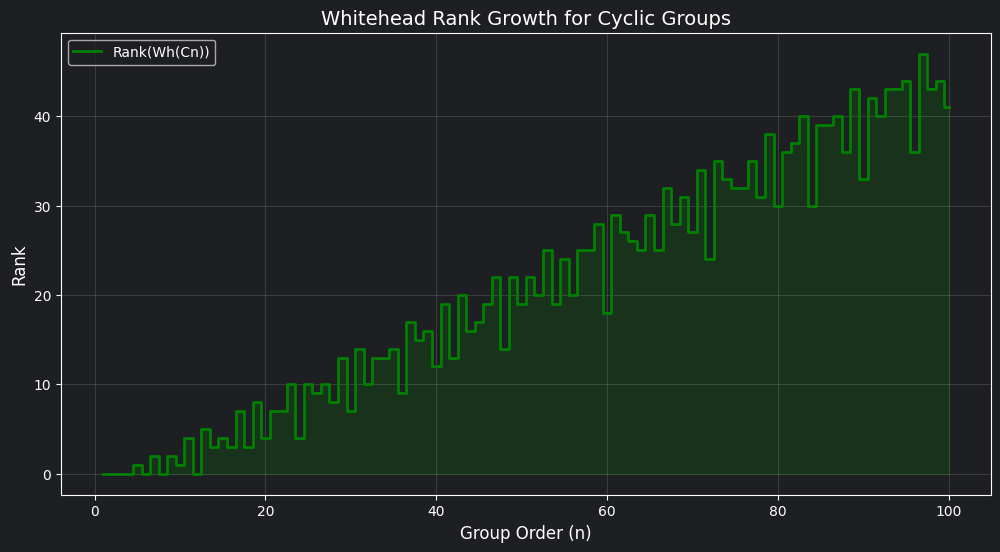

In [6]:
# Plotting the Whitehead rank for cyclic groups C_n
ns = np.arange(1, 101)
ranks = [cyclic_whitehead_rank(n) for n in ns]

fig, ax = plt.subplots(figsize=(12, 6))
ax.step(ns, ranks, where='mid', color='green', lw=2, label='Rank(Wh(Cn))')
ax.fill_between(ns, ranks, step='mid', alpha=0.2, color='green')

ax.set_title('Whitehead Rank Growth for Cyclic Groups', fontsize=14)
ax.set_xlabel('Group Order (n)', fontsize=12)
ax.set_ylabel('Rank', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

## Failure Modes

1. **Non-Abelian Whitehead Groups**: Computing the exact structure of $Wh(G)$ for non-abelian $G$ is an open research problem. `pySurgery` provides ranks and lower bounds based on known literature.
2. **Infinite Nil Groups**: The Nil-terms in the BHS theorem are notoriously difficult to compute and can be non-zero for non-regular rings.
3. **Abelianization Dependence**: Many $K_1$ results depend on the abelianization $G/[G,G]$. If the fundamental group presentation is too complex, abelianization might fail.


In [7]:
# Example of a complex group where rank might only be an estimate
pi1_complex = FundamentalGroup(
    generators=['a', 'b', 'c'], 
    relations=[['a', 'b', 'a^-1', 'b^-1', 'c'], ['c', 'a', 'c^-1', 'a^-1']]
)
wh_complex = compute_whitehead_group(pi1_complex)
print(f'Complex Group: Wh rank approx = {wh_complex.rank}')
print(f'Exact? {wh_complex.exact}')

Complex Group: Wh rank approx = 0
Exact? False


## Summary Checklist
- [x] Computed Whitehead ranks for trivial, free, and cyclic groups.
- [x] Applied the Bass-Heller-Swan logic to free abelian groups.
- [x] Identified the role of $Wh(G)$ in s-cobordism obstructions.
- [x] Visualized the growth of algebraic K-theory invariants.

## Exercises
1. **The Prime Rule**: Verify that for prime $p < 5$, $Wh(C_p) = 0$. What is the first prime where it is non-zero?
2. **BHS Recursion**: Using the BHS formula, manually calculate $Wh(G 	imes \mathbb{Z} 	imes \mathbb{Z})$ assuming $Wh(G)=0$ and $K_0(\mathbb{Z}[G])=0$.
3. **Whitehead of Finitely Generated Groups**: Build a fundamental group $\mathbb{Z} \oplus C_2$ and compute its Whitehead rank.
4. **Projective Modules**: Research the meaning of $K_0(\mathbb{Z}[G])$ and explain why it is called the "finiteness obstruction."
5. **Geometry of Torsion**: Draw a 2D cobordism with non-vanishing Whitehead torsion (conceptual sketch).

## Key Takeaways
- **Whitehead Torsion** is the final gatekeeper for homeomorphism classification via s-cobordisms.
- **Bass-Heller-Swan** provides a recursive path to compute K-groups for a wide class of groups.
- Most "small" groups used in toy examples (like $\mathbb{Z}^n$ or small cyclic groups) have **rank 0 Whitehead groups**.
- $K$-theory connects the **algebra of the group ring** to the **geometry of cobordisms**.

**Ready for [11 - Wall Groups and Obstruction Primer](./11_wall_groups_and_obstruction_primer.ipynb)**
